<a href="https://colab.research.google.com/github/Togarucharitha/BEE-102-Spring-2025-Assignment/blob/main/05_V_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 5


This solution generates a V-plot, a heatmap that visualizes DNA fragment sizes relative to protein binding sites. The goal is to reveal protected regions where proteins bind—typically forming a "V" shape due to fragment distributions flanking the center.

The process begins by parsing a tab-delimited file where each line represents a fragment and its associated binding site. From each line, the script calculates:

X: the distance from the fragment center to the protein binding center,

Y: the fragment length,

Z: the count of how often a particular (X, Y) pair occurs.

All (X, Y) occurrences are aggregated into a count_map. These are used to build a 2D matrix (heatmap) with fragment length (Y) on the vertical axis and position relative to the protein binding center (X) on the horizontal axis. The values in the matrix represent how many times a fragment of length Y occurred at position X.

Finally, the heatmap is rendered using Seaborn with an inverted Y-axis to match biological conventions, revealing the characteristic V-pattern of protected fragments near binding sites.

In [ ]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Compressed input file
file_path = "/content/data.bed"

# Count occurrences of (X, Y)
count_map = defaultdict(int)

# Open and read compressed file
with open(file_path, 'r') as file:
    for line in file:
        fields = line.strip().split('\t')

        # Check if the line has enough fields before accessing them
        if len(fields) >= 10:
            # Center of protein-bound region (col 3 & 4)
            center_protein = (int(fields[2]) + int(fields[3])) // 2

            # Center of fragment (col 9 & 10)
            center_fragment = (int(fields[8]) + int(fields[9])) // 2

            # X = offset from protein binding center
            x = center_fragment - center_protein

            # Y = fragment length
            y = int(fields[9]) - int(fields[8])

            # Count the (X, Y) occurrence
            count_map[(x, y)] += 1
        #else:
        #    print(f"Skipping line due to insufficient fields: {line.strip()}")  # Optional: Print skipped lines

print("Total unique (X, Y) pairs:", len(count_map))

Total unique (X, Y) pairs: 122906


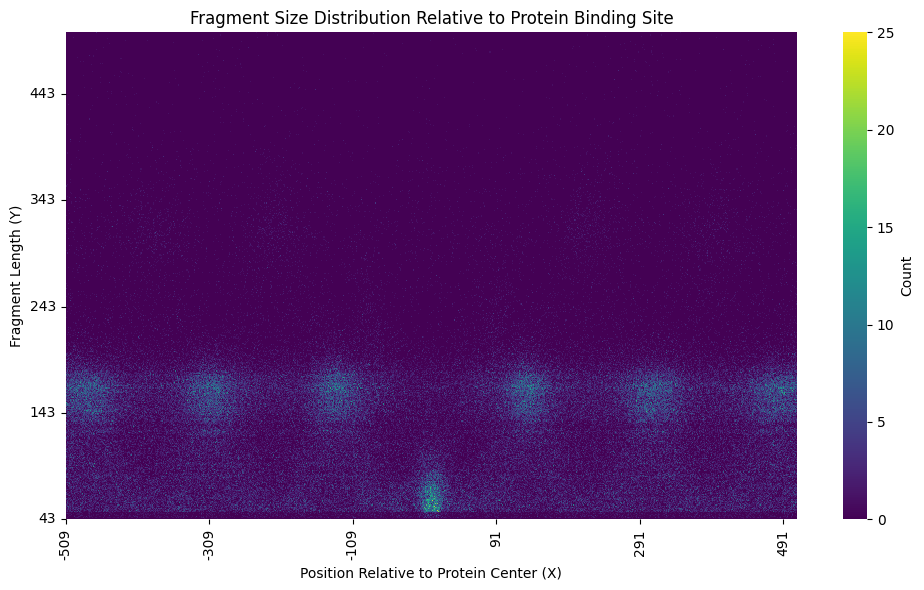

In [ ]:
# Create sorted unique lists of X and Y
x_vals = sorted({x for x, _ in count_map})
y_vals = sorted({y for _, y in count_map})

# Index maps for matrix placement
x_index = {x: i for i, x in enumerate(x_vals)}
y_index = {y: i for i, y in enumerate(y_vals)}

# Create heatmap matrix
heatmap = np.zeros((len(y_vals), len(x_vals)))
for (x, y), count in count_map.items():
    heatmap[y_index[y], x_index[x]] = count

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap, cmap="viridis", cbar_kws={'label': 'Count'})
plt.gca().invert_yaxis()
plt.xticks(np.arange(len(x_vals))[::200], x_vals[::200])
plt.yticks(np.arange(len(y_vals))[::100], y_vals[::100])
plt.title("Fragment Size Distribution Relative to Protein Binding Site")
plt.xlabel("Position Relative to Protein Center (X)")
plt.ylabel("Fragment Length (Y)")
plt.tight_layout()
plt.show()